In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import numpy as np
import os

In [2]:
data_dir = "/kaggle/input/fl-fer-aug"  
IMG_SIZE = 224
BATCH_SIZE = 16

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # transforms.RandomRotation(30),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# No Augmentation was applied for fair evaluation between the architectures

In [4]:
full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)

In [5]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

In [6]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")

Classes: ['Natural', 'anger', 'fear', 'joy', 'sadness', 'surprise']


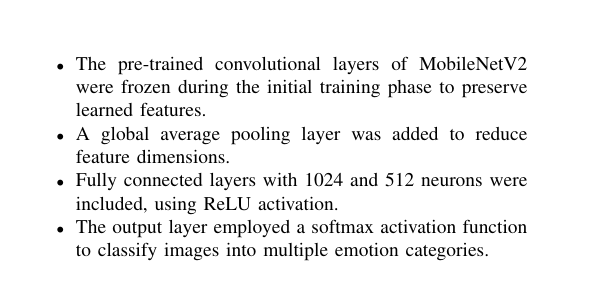

In [7]:
mobilenet = models.mobilenet_v2(weights=True)

# Freeze all convolutional layers initially as in the original paper
for param in mobilenet.features.parameters():
    param.requires_grad = False

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 114MB/s] 


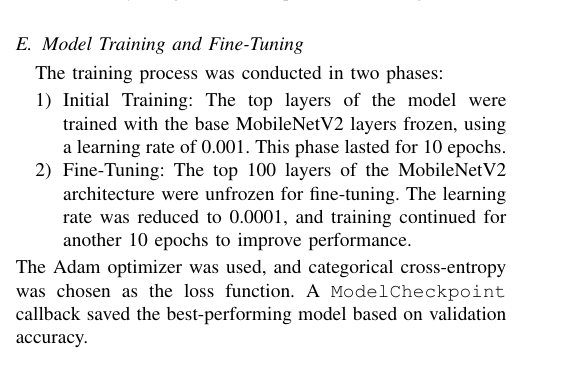

In [8]:
# Replace classifier with your custom FC layers
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(mobilenet.last_channel, 1024),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, num_classes)
)


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = mobilenet.to(device)

cuda


In [10]:
criterion = nn.CrossEntropyLoss()
## orginal training was does with Adam optimizar with 0.01 lr 
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [11]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import numpy as np
import torch

def evaluate_metrics_per_class(model, val_loader, device, class_names, verbose=True):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, average=None, zero_division=0
    )

    # Overall accuracy
    cm = confusion_matrix(all_labels, all_preds)
    acc = np.trace(cm) / np.sum(cm)

    # Print table ONLY if verbose is True (to avoid spamming console every epoch if you prefer)
    if verbose:
        print("\nClass\tPrecision\tRecall\tF1-Score\tSupport")
        for i, cls in enumerate(class_names):
            print(f"{cls:10}\t{precision[i]:.2f}\t\t{recall[i]:.2f}\t{f1[i]:.2f}\t\t{support[i]}")

        # Macro and Weighted averages
        precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='macro', zero_division=0
        )
        print(f"Accuracy: {acc:.2f}, Macro Avg: Prec={precision_macro:.2f}, Recall={recall_macro:.2f}, F1={f1_macro:.2f}")

    return acc, precision, recall, f1, support


In [12]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, class_names, phase_name="Training"):
    best_acc = 0.0
    
    # Initialize variables to store the metrics of the BEST model
    best_precision_arr = None
    best_recall_arr = None
    best_f1_arr = None
    best_support_arr = None

    for epoch in range(epochs):
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.double() / len(train_loader.dataset)

        # Evaluate
        # Note: You can set verbose=False here if you don't want the full table every single epoch
        val_acc, precision_arr, recall_arr, f1_arr, support_arr = evaluate_metrics_per_class(
            model, val_loader, device, class_names, verbose=True 
        )
        
        # Logging one-liner
        precision_macro = precision_arr.mean()
        recall_macro = recall_arr.mean()
        f1_macro = f1_arr.mean()
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Acc: {val_acc:.4f} | F1 Macro: {f1_macro:.4f}")

        # --- SAVE BEST MODEL AND METRICS ---
        if val_acc > best_acc:
            best_acc = val_acc
            
            # Capture the arrays from this specific epoch
            best_precision_arr = precision_arr
            best_recall_arr = recall_arr
            best_f1_arr = f1_arr
            best_support_arr = support_arr
            
            torch.save(model.state_dict(), "best_mobilenetv2_emotion.pth")
            print("  -> Saved new best model.")

    # --- FINAL REPORT ---
    print("="*60)
    print(f" TRAINING COMPLETE. BEST VALIDATION ACCURACY: {best_acc:.4f}")
    print("="*60)
    print(f"{'Class':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'Support':<10}")
    print("-" * 65)
    
    if best_precision_arr is not None:
        for i, cls in enumerate(class_names):
            print(f"{cls:<15} | "
                  f"{best_precision_arr[i]:.4f}     | "
                  f"{best_recall_arr[i]:.4f}     | "
                  f"{best_f1_arr[i]:.4f}     | "
                  f"{best_support_arr[i]}")
        
        # Calculate Macro Average for the Best Model
        macro_prec = best_precision_arr.mean()
        macro_rec = best_recall_arr.mean()
        macro_f1 = best_f1_arr.mean()
        
        print("-" * 65)
        print(f"{'MACRO AVG':<15} | {macro_prec:.4f}     | {macro_rec:.4f}     | {macro_f1:.4f}     | {best_support_arr.sum()}")
    else:
        print("No best model metrics recorded (did training run?)")
    print("="*60)

In [15]:
print("🔹 Initial Training (Frozen Base Layers)...")
train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=100, class_names=class_names ,phase_name="Initial Training")

🔹 Initial Training (Frozen Base Layers)...

Class	Precision	Recall	F1-Score	Support
Natural   	0.84		0.19	0.32		108
anger     	0.33		0.01	0.02		80
fear      	0.00		0.00	0.00		26
joy       	0.64		1.00	0.78		494
sadness   	0.21		0.09	0.13		86
surprise  	0.00		0.00	0.00		47
Accuracy: 0.62, Macro Avg: Prec=0.34, Recall=0.22, F1=0.21
Epoch [1/100] | Loss: 1.2721 | Train Acc: 0.5662 | Val Acc: 0.6219 | F1 Macro: 0.2077
  -> Saved new best model.

Class	Precision	Recall	F1-Score	Support
Natural   	0.63		0.45	0.53		108
anger     	0.62		0.06	0.11		80
fear      	0.00		0.00	0.00		26
joy       	0.66		0.99	0.79		494
sadness   	0.32		0.07	0.11		86
surprise  	0.00		0.00	0.00		47
Accuracy: 0.65, Macro Avg: Prec=0.37, Recall=0.26, F1=0.26
Epoch [2/100] | Loss: 1.1365 | Train Acc: 0.6117 | Val Acc: 0.6504 | F1 Macro: 0.2578
  -> Saved new best model.

Class	Precision	Recall	F1-Score	Support
Natural   	0.54		0.62	0.58		108
anger     	0.44		0.44	0.44		80
fear      	0.00		0.00	0.00		26
joy       	0.75		0.9

In [17]:
for param in list(model.features.parameters())[-100:]:
    param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)
print(" Fine-Tuning (top 100 layers)...")
train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=10, class_names=class_names)

 Fine-Tuning (top 100 layers)...

Class	Precision	Recall	F1-Score	Support
Natural   	0.59		0.80	0.67		108
anger     	0.60		0.69	0.64		80
fear      	0.65		0.58	0.61		26
joy       	0.92		0.94	0.93		494
sadness   	0.63		0.31	0.42		86
surprise  	0.71		0.53	0.61		47
Accuracy: 0.80, Macro Avg: Prec=0.68, Recall=0.64, F1=0.65
Epoch [1/10] | Loss: 0.6442 | Train Acc: 0.7899 | Val Acc: 0.7967 | F1 Macro: 0.6472
  -> Saved new best model.

Class	Precision	Recall	F1-Score	Support
Natural   	0.67		0.81	0.73		108
anger     	0.71		0.69	0.70		80
fear      	0.63		0.65	0.64		26
joy       	0.91		0.95	0.93		494
sadness   	0.54		0.35	0.42		86
surprise  	0.69		0.53	0.60		47
Accuracy: 0.81, Macro Avg: Prec=0.69, Recall=0.66, F1=0.67
Epoch [2/10] | Loss: 0.5235 | Train Acc: 0.8132 | Val Acc: 0.8145 | F1 Macro: 0.6720
  -> Saved new best model.

Class	Precision	Recall	F1-Score	Support
Natural   	0.78		0.83	0.81		108
anger     	0.69		0.76	0.73		80
fear      	0.73		0.73	0.73		26
joy       	0.92		0.96	0.94		494
